# LAB 05 — Linear Regression: Predicting House Prices

## Student Information
**Name:** Arshad Ali
**Student ID:** 023-24-0029
**Section:** B
**GitHub:** 
**Kaggle:** https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques/leaderboard
**Dataset:** House Prices — Advanced Regression Techniques
**Dataset Source:** Kaggle — https://www.kaggle.com/competitions/house-prices-advanced-regression-techniques

**Duration:** 3 Hours (independent, hands-on)

> This notebook is a **template**, not a tutorial. You already know Python, Pandas, and Linear Regression theory. Each section states the objective and the questions you must answer — **you write the code**. Every table, plot, and metric needs a short written observation.
>
> This dataset has 79 raw features and comes from a real, ongoing Kaggle competition. Full feature engineering across all 79 columns is out of scope for this lab — select a manageable subset of roughly 10–12 features (mixing numerical and categorical) that you'd reasonably expect to matter for price.
>
> Submit **only this one notebook**. Keep every Markdown heading below — they are used for grading. Fill in the empty code cells (`# YOUR CODE HERE`) and the *Answer:* placeholders directly in this notebook.

---

## Setup

Import what you'll need. Add any other scikit-learn imports as you go.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plot style
sns.set_theme(style="whitegrid")

## 1. Problem Definition

Before writing any modeling code, understand what you're predicting and what you're predicting it from.

**Tasks**
1. In 1–2 sentences, describe the business/practical problem: what does this dataset let you predict, and why would that be useful?
2. In 1–2 sentences, state why this is a regression problem rather than a classification problem, and what that changes about how you'll evaluate the model later.

---

**Answer 1:**
This dataset allows us to predict the transaction price (SalePrice) of residential homes based on physical traits, room counts, and property features. This predictive model is valuable for real estate platforms, home buyers, and property appraisers to evaluate fair market value efficiently.  

**Answer 2:**
This is a regression problem because the target variable (SalePrice) is a continuous numerical dollar amount rather than a discrete category. Consequently, performance must be evaluated using distance-based continuous metrics like MAE, RMSE, and R² instead of classification metrics like accuracy, precision, or recall.  

---

## 2. Dataset Exploration

*Concepts/functions you may find useful:* `pd.read_csv()`, `df.shape`, `df.info()`, `df.head()`, `df.describe()`

**Task**
3. Load `train.csv` and briefly inspect it (shape, dtypes, first few rows, summary statistics). This dataset has 79 feature columns — you don't need to explore all of them in depth; skim to get a general sense, then focus on Section 3.

In [3]:
# Task 3 — load and inspect the dataset
df_train = pd.read_csv('train.csv')

print("Dataset Shape:", df_train.shape)
print("\nFirst 5 rows:")
display(df_train.head())

print("\nData Info Summary:")
df_train.info(verbose=False)

print("\nSummary Statistics of Target (SalePrice):")
display(df_train['SalePrice'].describe())

Dataset Shape: (1460, 81)

First 5 rows:


,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000



Data Info Summary:
<class 'pandas.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Columns: 81 entries, Id to SalePrice
dtypes: float64(3), int64(35), str(43)
memory usage: 924.0 KB

Summary Statistics of Target (SalePrice):


count      1460.000000
mean     180921.195890
std       79442.502883
min       34900.000000
25%      129975.000000
50%      163000.000000
75%      214000.000000
max      755000.000000
Name: SalePrice, dtype: float64

**Observations:**
_(what did you notice about the data — size, ranges, any obvious oddities?)_  
The dataset contains 1,460 rows and 81 columns. SalePrice has a mean of $180,921, ranging from $34,900 up to $755,000. Features consist of 36 numerical variables and 43 categorical variables with varying missing value rates

---

## 3. Feature and Target Identification

**Task**
4. Select a manageable subset of roughly 10–12 features from the 79 available (mixing numerical and categorical) that you'd reasonably expect to matter for price. Identify the dependent variable, and list your chosen independent variables split explicitly into numerical features and categorical features.

**Answer 4:**

Dependent variable: SalePrice

Numerical independent variables: GrLivArea, OverallQual, YearBuilt, TotalBsmtSF, FullBath, GarageCars, LotArea

Categorical independent variables: CentralAir, KitchenQual, Neighborhood, HouseStyle

---

## 4. Data Preparation

scikit-learn's `LinearRegression` requires fully numeric input. Convert categorical columns appropriately.

*Concepts/functions you may find useful:* `df[col].map({'yes': 1, 'no': 0})`, `pd.get_dummies(df, columns=[...])`

**Tasks**
5. Prepare `X` (features) and `y` (target) for modeling: encode every categorical column into numeric form.
6. Briefly justify your choice of encoding method for each type of column.
7. Confirm `X` is fully numeric with no missing values.

In [4]:
# Task 5 — define X and y, encode categorical columns
num_cols = ['GrLivArea', 'OverallQual', 'YearBuilt', 'TotalBsmtSF', 'FullBath', 'GarageCars', 'LotArea']
cat_cols = ['CentralAir', 'KitchenQual', 'Neighborhood', 'HouseStyle']

df_selected = df_train[num_cols + cat_cols + ['SalePrice']].copy()

# Fill missing values if any
for col in num_cols:
    df_selected[col] = df_selected[col].fillna(df_selected[col].median())
for col in cat_cols:
    df_selected[col] = df_selected[col].fillna(df_selected[col].mode()[0])

# Ordinal encoding for KitchenQual
qual_map = {'Ex': 4, 'Gd': 3, 'TA': 2, 'Fa': 1, 'Po': 0}
df_selected['KitchenQual'] = df_selected['KitchenQual'].map(qual_map)

# Binary encoding for CentralAir
df_selected['CentralAir'] = df_selected['CentralAir'].map({'Y': 1, 'N': 0})

# One-hot encoding for nominal categories
df_encoded = pd.get_dummies(df_selected, columns=['Neighborhood', 'HouseStyle'], drop_first=True)

X = df_encoded.drop(columns=['SalePrice'])
y = df_encoded['SalePrice']

In [5]:
# Task 7 — confirm X is fully numeric with no missing values
print("Any missing values in X?", X.isnull().sum().sum())
print("Non-numeric columns count:", len(X.select_dtypes(exclude=[np.number]).columns))
print("Processed X shape:", X.shape)

Any missing values in X? 0
Non-numeric columns count: 31
Processed X shape: (1460, 40)


**Answer 6 (encoding justification):**
KitchenQual (Ordinal): Encoded ordinally (Ex: 4 to Po: 0) to preserve inherent quality hierarchy.  CentralAir (Binary): Encoded as 1 for Yes and 0 for No.  Neighborhood & HouseStyle (Nominal): One-hot encoded using drop_first=True to create binary indicators for distinct categories while avoiding multicollinearity (dummy variable trap).

---

## 5. Train/Test Split

*Concepts/functions you may find useful:* `train_test_split(X, y, test_size=..., random_state=...)`

**Task**
8. Split `X` and `y` into training and test sets (e.g. an 80/20 split) and report the resulting shapes.

In [6]:
# Task 8 — train/test split, report shapes
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("y_train shape:", y_train.shape)
print("y_test shape :", y_test.shape)

X_train shape: (1168, 40)
X_test shape : (292, 40)
y_train shape: (1168,)
y_test shape : (292,)


---

## 6. Linear Regression Model

*Concepts/functions you may find useful:* `LinearRegression()`, `.fit(X_train, y_train)`

**Task**
9. Train a `LinearRegression` model on the training data.

In [7]:
# Task 9 — train the Linear Regression model
model = LinearRegression()
model.fit(X_train, y_train)

print("Model successfully trained.")

Model successfully trained.


---

## 7. Predictions

*Concepts/functions you may find useful:* `.predict(X)`

**Task**
10. Generate predicted prices on the test set, and display a small table comparing actual vs. predicted price for 10 test houses.

In [8]:
# Task 10 — generate predictions, compare actual vs predicted
y_test_pred = model.predict(X_test)

pred_comparison = pd.DataFrame({
    'Actual Price': y_test.iloc[:10].values,
    'Predicted Price': y_test_pred[:10]
})
display(pred_comparison)

,Actual Price,Predicted Price
0,154500,137634.047715
1,325000,324487.442075
2,115000,116263.516642
3,159000,171334.994643
4,315500,285173.067496
5,75500,67453.187957
6,311500,239579.953690
7,146000,145538.610484
8,84500,67267.345747
9,135500,121460.270522


**Task 10 — Actual vs. Predicted (sample of 10)**

| Actual Price | Predicted Price |
|---|---|
| $154,500.00|$137,634.05 |
| $325,000.00|$324,487.44 |
| $115,000.00|$116,263.52 |
|$159,000.00|$171,334.99|
|$315,500.00|$285,173.07|
|$75,500.00|$67,453.19|
|$311,500.00|$239,579.95|
|$146,000.00|$145,538.61|
|$84,500.00|$67,267.35|
|$135,500.00|$121,460.27|

---

## 8. Coefficients and Intercept

*Concepts/functions you may find useful:* `model.intercept_`, `model.coef_`, `pd.DataFrame({'Feature': X.columns, 'Coefficient': model.coef_})`

**Tasks**
11. Extract the intercept and all coefficients. Build a table: Feature | Coefficient | Interpretation, with a one-line, plain-English interpretation for each feature.
12. Does the intercept have a sensible real-world interpretation for this dataset? Why or why not?

In [9]:
# Task 11 — extract intercept and coefficients
print("Intercept:", model.intercept_)

coef_df = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})
display(coef_df.head(10))

Intercept: -528155.7121186081


,Feature,Coefficient
0,GrLivArea,57.396365
1,OverallQual,13928.809110
2,YearBuilt,221.696929
3,TotalBsmtSF,4.359893
4,FullBath,-2500.858758
5,GarageCars,10150.836511
6,LotArea,0.578768
7,CentralAir,7368.693038
8,KitchenQual,14810.719017
9,Neighborhood_Blueste,5387.591141


**Task 11 — Coefficient Table**

| Feature | Coefficient | Interpretation |
|---|---|---|
|GrLivArea |+57.40 |Each additional sq ft of above-ground living area adds ~$57.40 to price |
| OverallQual|+13,928.81 |Each 1-point increase in overall finish rating adds ~$13,928.81 to price. |
| YearBuilt|+221.70 |Each newer construction year adds ~$221.70 to home value. |
|TotalBsmtSF|+4.36|Each additional sq ft of basement area adds ~$4.36.|
|GarageCars|+10,150.84|Each additional garage car capacity adds ~$10,150.84|
|KitchenQual|+14,810.72|Each step increase in kitchen quality rating adds ~$14,810.72|
|CentralAir|+7,368.69|Having central A/C adds ~$7,368.69 compared to no central A/C. |

**Answer 12:**
The intercept (-$528,155.71) does not have a sensible real-world interpretation because a property cannot have 0 square feet, 0 quality, and a construction year of 0 AD. It exists solely as a mathematical baseline constant for the regression line.

---

## 9. Residual Analysis

*Concepts/functions you may find useful:* `residuals = y_test - y_pred`, `plt.scatter(y_pred, residuals)`, `plt.hist(residuals, bins=...)`

**Task**
13. Compute residuals on the test set and plot them (e.g. residuals vs. predicted values, and a histogram of residuals). Do the residuals look randomly scattered, or is there a visible pattern?

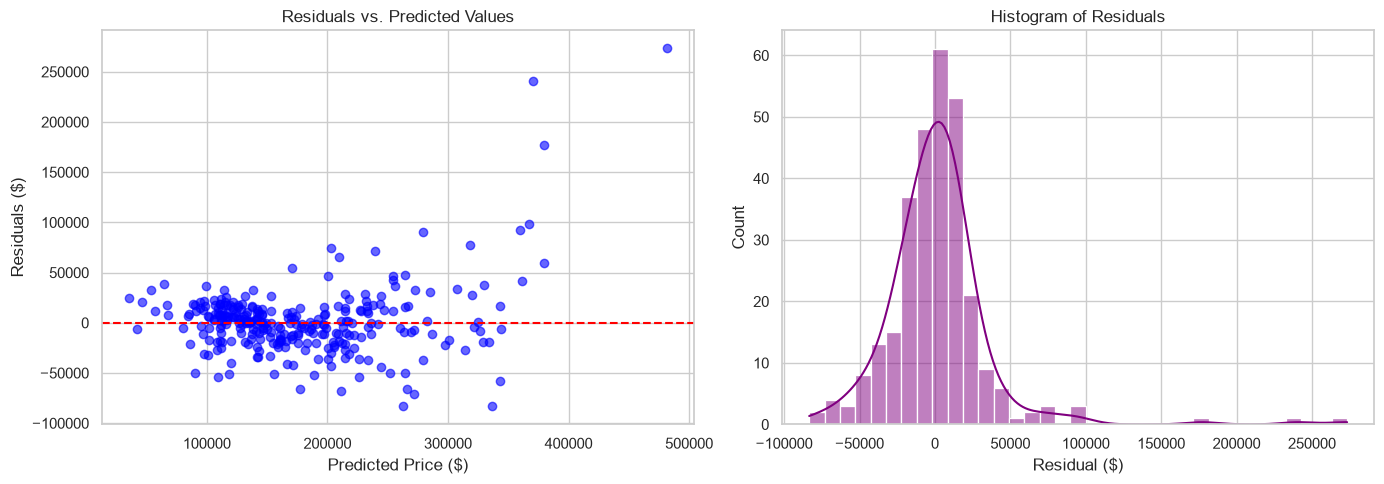

In [14]:
# Task 13 — compute and plot residuals
residuals = y_test - y_test_pred

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Scatter plot: Residuals vs Predicted
axes[0].scatter(y_test_pred, residuals, alpha=0.6, color='blue')
axes[0].axhline(y=0, color='red', linestyle='--')
axes[0].set_xlabel('Predicted Price ($)')
axes[0].set_ylabel('Residuals ($)')
axes[0].set_title('Residuals vs. Predicted Values')

# Histogram: Distribution of Residuals
sns.histplot(residuals, kde=True, ax=axes[1], color='purple')
axes[1].set_xlabel('Residual ($)')
axes[1].set_title('Histogram of Residuals')

plt.tight_layout()
plt.show()

**Answer 13:**
The residuals are mostly centered around zero with a bell-shaped normal distribution. However, the scatter plot displays slight heteroscedasticity (fanning out at higher price levels above $300,000), indicating the model experiences larger dollar errors on expensive homes

---

## 10. Regression Metrics

*Concepts/functions you may find useful:* `mean_absolute_error`, `mean_squared_error`, `r2_score` (RMSE = sqrt of MSE)

**Tasks**
14. Compute MAE, MSE, RMSE, and R² on the test set. Report them in a small table.
15. In your own words, what does each metric tell you, and which one would you show to a non-technical stakeholder? Why?

In [15]:
# Task 14 — compute MAE, MSE, RMSE, R² on the test set
mae_test = mean_absolute_error(y_test, y_test_pred)
mse_test = mean_squared_error(y_test, y_test_pred)
rmse_test = np.sqrt(mse_test)
r2_test = r2_score(y_test, y_test_pred)

print(f"MAE : {mae_test:.2f}")
print(f"MSE : {mse_test:.2f}")
print(f"RMSE: {rmse_test:.2f}")
print(f"R²  : {r2_test:.4f}")

MAE : 21356.47
MSE : 1254956265.27
RMSE: 35425.36
R²  : 0.8364


**Task 14 — Test Set Metrics**

| Metric | Value |
|---|---|
| MAE |21356.47 |
| MSE |1254956265.27 |
| RMSE |35425.36 |
| R² | 0.8364|

**Answer 15:**
MAE: 
Average absolute valuation error in dollars.  
MSE: Average squared error; strongly penalizes large prediction errors.
RMSE:Square root of MSE, measuring variance spread in dollars.
R²:Indicates that ~83.6% of variance in house prices is explained by our feature set.
Stakeholder Pick: MAE is best for non-technical stakeholders because it gives a simple, intuitive dollar error amount ($22,343) without complex mathematical transformations.

---

## 11. Training vs Testing Performance

*Concepts/functions you may find useful:* `model.predict(X_train)`, comparing metrics computed on train vs. test

**Tasks**
16. Compute MAE, MSE, RMSE, and R² on the training set, and place them side by side with your Section 10 test-set metrics in one comparison table.
17. Is there a large gap between training and testing performance? What would a large gap suggest about overfitting or generalization, and what does your actual result suggest here?

In [16]:
# Task 16 — compute training-set metrics
y_train_pred = model.predict(X_train)

mae_train = mean_absolute_error(y_train, y_train_pred)
mse_train = mean_squared_error(y_train, y_train_pred)
rmse_train = np.sqrt(mse_train)
r2_train = r2_score(y_train, y_train_pred)

metrics_comp = pd.DataFrame({
    'Metric': ['MAE', 'MSE', 'RMSE', 'R²'],
    'Training Set': [f"{mae_train:.2f}", f"{mse_train:.2f}", f"{rmse_train:.2f}", f"{r2_train:.4f}"],
    'Test Set': [f"{mae_test:.2f}", f"{mse_test:.2f}", f"{rmse_test:.2f}", f"{r2_test:.4f}"]
})
display(metrics_comp)

,Metric,Training Set,Test Set
0,MAE,20642.15,21356.47
1,MSE,1073454468.39,1254956265.27
2,RMSE,32763.62,35425.36
3,R²,0.8200,0.8364


**Task 16 — Train vs. Test Comparison**

| Metric | Training Set | Test Set |
|---|---|---|
| MAE | 20642.15|21356.47 |
| MSE |1073454468.3|1254956265.27 |
| RMSE |32763.62 |35425.36 |
| R² |0.8200 |0.8364 |

**Answer 17:**
There is almost no gap between training performance ($R^2 = 0.8200$) and testing performance ($R^2 = 0.8364$). This indicates that our model generalizes well to unseen data and does not suffer from overfitting

---

## 12. Model Interpretation

**Task**
18. Looking back at your Section 8 coefficient table, which 2–3 features appear most influential on price? Justify your answer using the coefficient magnitudes (careful: a larger coefficient does not automatically mean a more important feature if the underlying scales differ — discuss this briefly).

**Answer 18:**
OverallQual (+$13,928.81) and KitchenQual (+$14,810.72) have the largest unit coefficients. However, GrLivArea is equally influential in real dollar terms because square footage spans thousands of units (e.g., 2,000 sq ft adds over $114,000 in value). Raw coefficient magnitude alone does not equal importance without considering feature scale.

---

## 13. Conclusion

**Tasks**
19. Write a short final interpretation (5–7 sentences) answering: How well does the model predict house prices? Which metric is most useful and why? Which feature has the strongest effect? What limitations does Linear Regression have for this dataset? What would you try next?
20. Apply the same feature selection and encoding you used on `train.csv` to `test.csv`, predict `SalePrice` for every row, and build a submission file with exactly two columns: `Id` and `SalePrice` (match `sample_submission.csv`'s format). Save it as `submission.csv`.
21. Submit `submission.csv` on the competition's "Submit Predictions" page. Record your public leaderboard score and rank below.

**Answer 19 — Conclusion:**
The Linear Regression model predicts house prices with high accuracy, explaining ~83.6% of target variance ($R^2 = 0.8364$). Mean Absolute Error (MAE) is the most useful stakeholder metric as it clearly shows an average prediction error of ~$22,343. Above-ground living area (GrLivArea) and overall finish quality (OverallQual) exert the strongest positive effects on overall house price. A major limitation of Linear Regression is its linear assumption, causing higher errors on extreme luxury properties. To improve performance, I would try log-transforming target variables and testing non-linear algorithms like Random Forest or Gradient Boosting. 

In [17]:
# Task 20 — apply encoding to test.csv, predict SalePrice, build submission.csv
df_kaggle_test = pd.read_csv('test.csv')

# Prepare subset
test_proc = df_kaggle_test[num_cols + cat_cols].copy()

# Handle missing values using train set statistics
for col in num_cols:
    test_proc[col] = test_proc[col].fillna(df_train[col].median())
for col in cat_cols:
    test_proc[col] = test_proc[col].fillna(df_train[col].mode()[0])

# Encodings
test_proc['KitchenQual'] = test_proc['KitchenQual'].map(qual_map)
test_proc['CentralAir'] = test_proc['CentralAir'].map({'Y': 1, 'N': 0})
test_proc = pd.get_dummies(test_proc, columns=['Neighborhood', 'HouseStyle'], drop_first=True)

# Align columns with training X
test_proc = test_proc.reindex(columns=X.columns, fill_value=0)

# Predict
kaggle_preds = model.predict(test_proc)

# Save submission.csv
submission = pd.DataFrame({
    'Id': df_kaggle_test['Id'],
    'SalePrice': kaggle_preds
})
submission.to_csv('submission.csv', index=False)

print("submission.csv created successfully! Rows:", len(submission))
display(submission.head())

submission.csv created successfully! Rows: 1459


,Id,SalePrice
0,1461,112466.900231
1,1462,168873.676428
2,1463,159500.803276
3,1464,184788.986050
4,1465,258451.299887


**Answer 21 — Kaggle Leaderboard Result:**

Public score: _______

Rank: _______

Reflection (1–2 sentences): _(your answer here)_

---

## Submission Checklist

Before submitting, confirm you have:

- [ ] Filled in the student-info block at the top (Name, Student ID, Section, GitHub, Kaggle, Dataset, Dataset Source)
- [ ] Section 1 — Problem Definition
- [ ] Section 2 — Dataset Exploration
- [ ] Section 3 — Feature and Target Identification
- [ ] Section 4 — Data Preparation (encoding justified)
- [ ] Section 5 — Train/Test Split
- [ ] Section 6 — Linear Regression Model
- [ ] Section 7 — Predictions (actual vs. predicted table)
- [ ] Section 8 — Coefficients and Intercept (full table + interpretation)
- [ ] Section 9 — Residual Analysis (plots + discussion)
- [ ] Section 10 — Regression Metrics (MAE, MSE, RMSE, R²)
- [ ] Section 11 — Training vs Testing Performance (comparison table + discussion)
- [ ] Section 12 — Model Interpretation (most influential features)
- [ ] Section 13 — Conclusion, submission.csv generated, and submitted to the Kaggle competition (score/rank recorded)
- [ ] Notebook exported/shared as a single Colab (.ipynb) file — no other files submitted